In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")

In [3]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


In [5]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [6]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [7]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     str           
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 3.3 MB


In [9]:
df['hour'] = df['date_time'].dt.hour

In [10]:
df[['date_time','hour']].head()

,date_time,hour
0,2012-10-02 09:00:00,9
1,2012-10-02 10:00:00,10
2,2012-10-02 11:00:00,11
3,2012-10-02 12:00:00,12
4,2012-10-02 13:00:00,13


In [11]:
df['day_of_week'] = df['date_time'].dt.day_name()

In [12]:
df[['date_time', 'day_of_week']].head()

,date_time,day_of_week
0,2012-10-02 09:00:00,Tuesday
1,2012-10-02 10:00:00,Tuesday
2,2012-10-02 11:00:00,Tuesday
3,2012-10-02 12:00:00,Tuesday
4,2012-10-02 13:00:00,Tuesday


In [13]:
df['month'] = df['date_time'].dt.month

In [14]:
df[['date_time','month']].head()

,date_time,month
0,2012-10-02 09:00:00,10
1,2012-10-02 10:00:00,10
2,2012-10-02 11:00:00,10
3,2012-10-02 12:00:00,10
4,2012-10-02 13:00:00,10


In [15]:
df['is_weekend'] = df['date_time'].dt.dayofweek >= 5

In [16]:
df['is_weekend'] = df['is_weekend'].astype(int)

In [17]:
df[['day_of_week','is_weekend']].head()

,day_of_week,is_weekend
0,Tuesday,0
1,Tuesday,0
2,Tuesday,0
3,Tuesday,0
4,Tuesday,0


In [18]:
df['rush_hour'] = df['hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0
)

In [19]:
df[['hour','rush_hour']].head(15)

,hour,rush_hour
0,9,1
1,10,0
2,11,0
3,12,0
4,13,0
5,14,0
6,15,0
7,16,1
8,17,1
9,18,1


In [20]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,is_weekend,rush_hour
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,0,1
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,0,0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,0,0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,0,0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,0,0


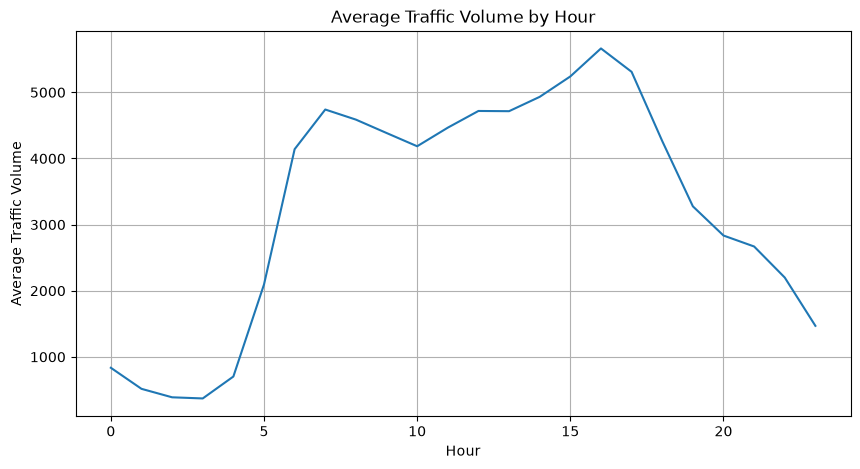

In [21]:
import matplotlib.pyplot as plt

hourly_traffic = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_traffic.index, hourly_traffic.values)
plt.title('Average Traffic Volume by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Traffic Volume')
plt.grid(True)

plt.show()

In [22]:
hourly_traffic.sort_values(ascending=False).head()

hour
16    5663.756539
17    5310.076048
15    5240.524302
14    4931.888776
7     4740.181337
Name: traffic_volume, dtype: float64

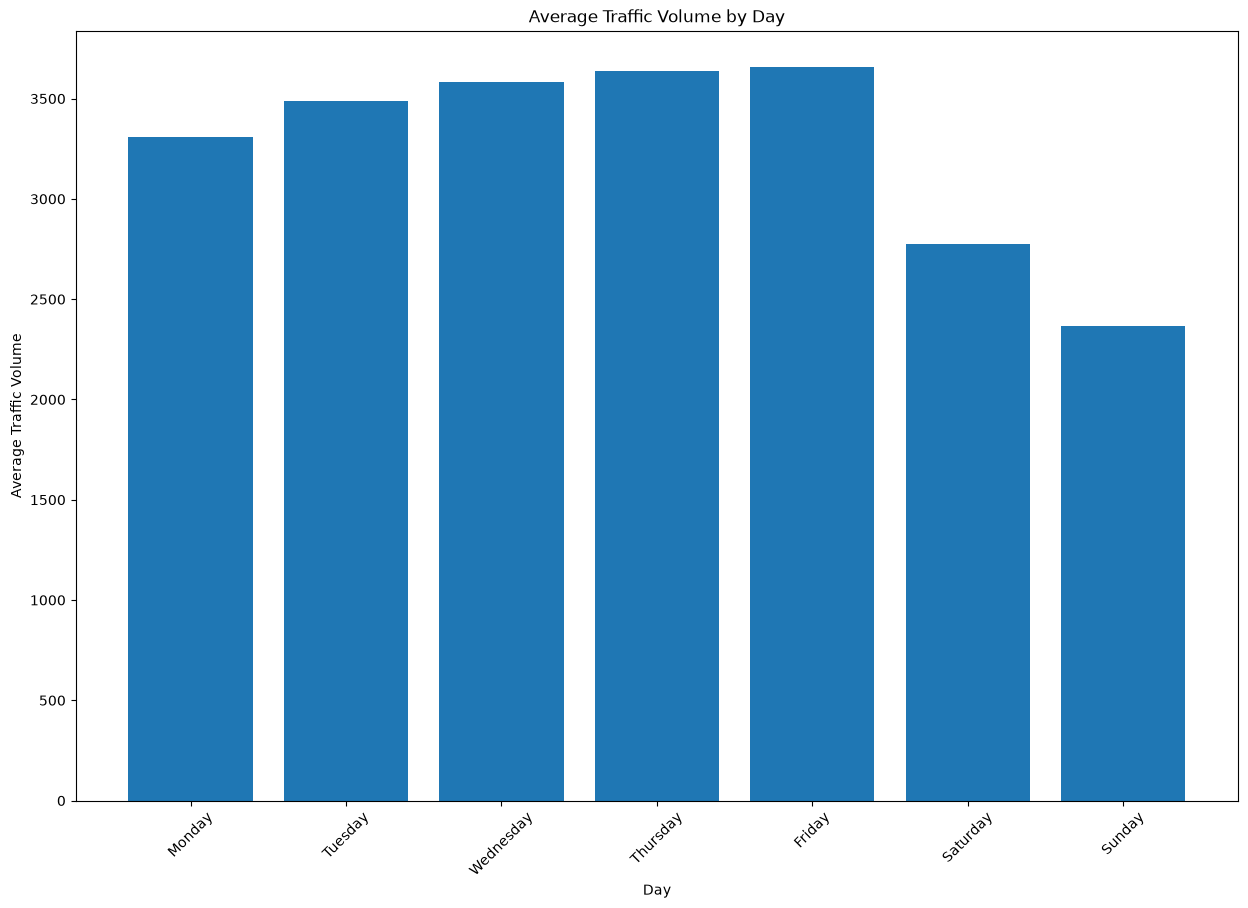

In [23]:
daily_traffic = df.groupby('day_of_week')['traffic_volume'].mean()

daily_traffic = daily_traffic.reindex([
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
])

plt.figure(figsize=(15,10))
plt.bar(daily_traffic.index, daily_traffic.values)

plt.title('Average Traffic Volume by Day')
plt.xlabel('Day')
plt.ylabel('Average Traffic Volume')

plt.xticks(rotation=45)
plt.show()

In [24]:
df['weather_main'].unique()

<StringArray>
[      'Clouds',        'Clear',         'Rain',      'Drizzle',
         'Mist',         'Haze',          'Fog', 'Thunderstorm',
         'Snow',       'Squall',        'Smoke']
Length: 11, dtype: str

In [25]:
df['weather_main'].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [26]:
weather_encoded = pd.get_dummies(
    df['weather_main'],
    prefix='weather',
    dtype=int
)

weather_encoded.head()

,weather_Clear,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,0,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0


In [27]:
weather_encoded.head()

,weather_Clear,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,0,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0


In [28]:
df = pd.concat([df, weather_encoded], axis=1)

In [29]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,...,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,...,1,0,0,0,0,0,0,0,0,0
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,...,1,0,0,0,0,0,0,0,0,0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,...,1,0,0,0,0,0,0,0,0,0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,...,1,0,0,0,0,0,0,0,0,0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,...,1,0,0,0,0,0,0,0,0,0


In [30]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'hour',
       'day_of_week', 'month', 'is_weekend', 'rush_hour', 'weather_Clear',
       'weather_Clouds', 'weather_Drizzle', 'weather_Fog', 'weather_Haze',
       'weather_Mist', 'weather_Rain', 'weather_Smoke', 'weather_Snow',
       'weather_Squall', 'weather_Thunderstorm'],
      dtype='str')

In [31]:
day_encoded = pd.get_dummies(
    df['day_of_week'],
    prefix='day',
    dtype=int
)

day_encoded.head()

,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0


In [32]:
df = pd.concat([df, day_encoded], axis=1)

In [33]:
day_encoded.head()

,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0


In [34]:
df['congestion_level'] = pd.qcut(
    df['traffic_volume'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [35]:
df[['traffic_volume', 'congestion_level']].head(10)

,traffic_volume,congestion_level
0,5545,High
1,4516,Medium
2,4767,High
3,5026,High
4,4918,High
5,5181,High
6,5584,High
7,6015,High
8,5791,High
9,4770,High


In [36]:
df['congestion_level'].value_counts()

congestion_level
Low       16070
Medium    16067
High      16067
Name: count, dtype: int64

In [37]:
features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'month',
    'is_weekend',
    'rush_hour'
]

In [38]:
weather_columns = [
    col for col in df.columns
    if col.startswith('weather_')
    and col not in ['weather_main', 'weather_description']
]

weather_columns

['weather_Clear',
 'weather_Clouds',
 'weather_Drizzle',
 'weather_Fog',
 'weather_Haze',
 'weather_Mist',
 'weather_Rain',
 'weather_Smoke',
 'weather_Snow',
 'weather_Squall',
 'weather_Thunderstorm']

In [39]:
day_columns = [col for col in df.columns if col.startswith('day_')]

day_columns

['day_of_week',
 'day_Friday',
 'day_Monday',
 'day_Saturday',
 'day_Sunday',
 'day_Thursday',
 'day_Tuesday',
 'day_Wednesday']

In [40]:
features = features + weather_columns + day_columns

len(features)

27

In [41]:
day_columns = [
    col for col in df.columns
    if col.startswith('day_')
    and col != 'day_of_week'
]

day_columns

['day_Friday',
 'day_Monday',
 'day_Saturday',
 'day_Sunday',
 'day_Thursday',
 'day_Tuesday',
 'day_Wednesday']

In [42]:
features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'month',
    'is_weekend',
    'rush_hour'
]

features = features + weather_columns + day_columns

len(features)

26

In [43]:
X = df[features]

y = df['congestion_level']

In [44]:
X.shape

(48204, 26)

In [45]:
y.shape

(48204,)

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.shape


(9641, 26)

In [50]:
X_test.shape

(9641, 26)

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [53]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [54]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array(['High', 'Low', 'Low', 'Low', 'High', 'Medium', 'High', 'High',
       'High', 'Medium'], dtype=object)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8981433461259205


In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.88      0.91      0.89      3238
         Low       0.96      0.94      0.95      3197
      Medium       0.85      0.85      0.85      3206

    accuracy                           0.90      9641
   macro avg       0.90      0.90      0.90      9641
weighted avg       0.90      0.90      0.90      9641



In [57]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[2944    1  293]
 [  25 3004  168]
 [ 378  117 2711]]


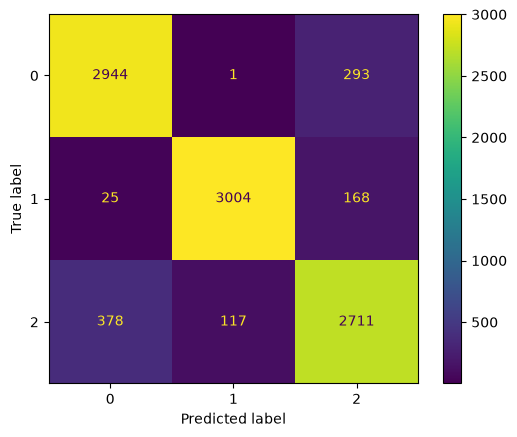

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot()
plt.show()

In [59]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,hour,0.593476
0,temp,0.149088
5,month,0.050828
7,rush_hour,0.045717
6,is_weekend,0.040019
3,clouds_all,0.035023
22,day_Sunday,0.017248
21,day_Saturday,0.010642
1,rain_1h,0.009729
20,day_Monday,0.006707


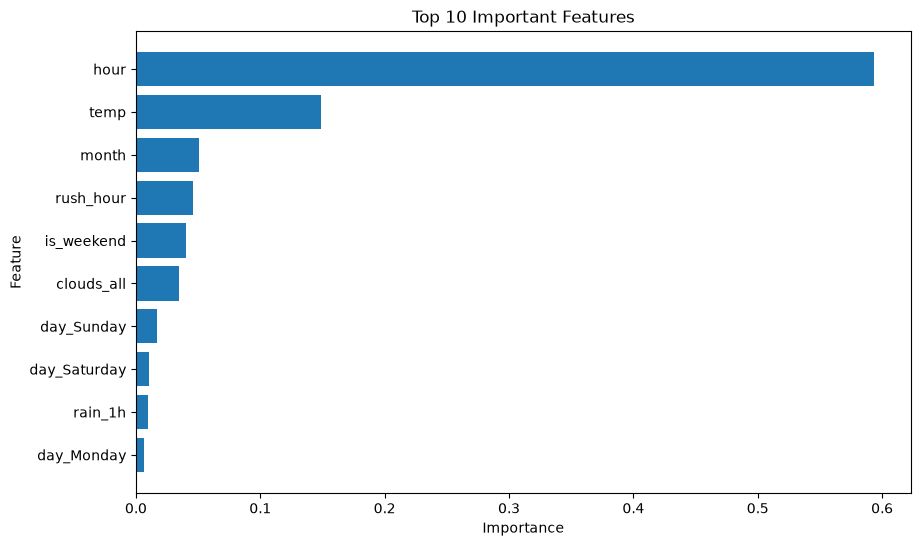

In [60]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()

plt.show()

In [61]:
import joblib

joblib.dump(rf_model, "../models/traffic_rf_model.pkl")

['../models/traffic_rf_model.pkl']

In [62]:
print(X.columns.tolist())

['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'month', 'is_weekend', 'rush_hour', 'weather_Clear', 'weather_Clouds', 'weather_Drizzle', 'weather_Fog', 'weather_Haze', 'weather_Mist', 'weather_Rain', 'weather_Smoke', 'weather_Snow', 'weather_Squall', 'weather_Thunderstorm', 'day_Friday', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']


In [63]:
import joblib

joblib.dump(X.columns.tolist(), "../models/feature_names.pkl")

print("Feature names saved!")

Feature names saved!
